In [21]:
import matplotlib
from matplotlib import pylab as plt
import pandas as pd
import numpy as np
import seaborn as sns

df = pd.read_csv('../Bank-Term-Deposit-Subscription-Prediction/Data/bank-additional/bank-additional-full.csv', sep=';')
print(f"columns of df:\n{df.columns}")

columns of df:
Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')


Calculating summary statistics for 'y'...

--- Summary Statistics for 'y' ---
Counts:
y
no     36548
yes     4640
Name: count, dtype: int64

Percentages:
y
no     88.734583
yes    11.265417
Name: count, dtype: float64
------------------------------------
Counts:
y
no     36548
yes     4640
Name: count, dtype: int64
饼图已成功保存到 y_distribution_pie_chart.png


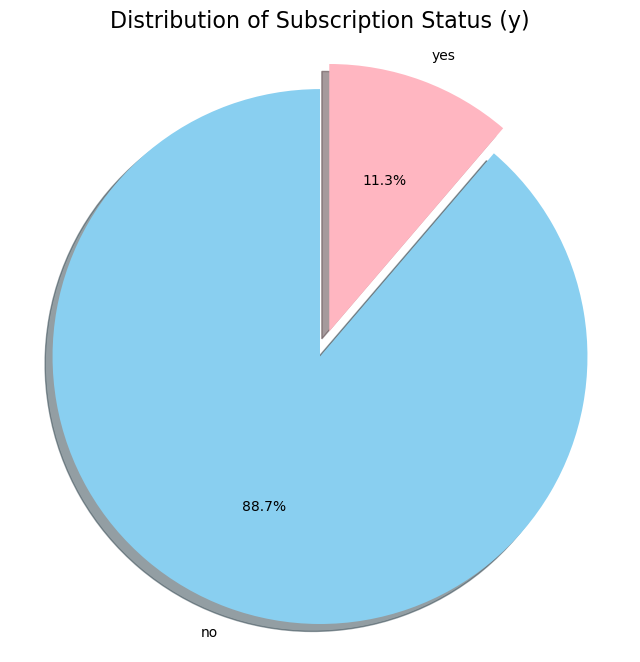

In [9]:
# eda for the target variable y
print("Calculating summary statistics for 'y'...")
total = len(df)
counts = df['y'].value_counts()
percentages = (counts / total) * 100

print("\n--- Summary Statistics for 'y' ---")
print("Counts:")
print(counts)
print("\nPercentages:")
print(percentages)
print("------------------------------------")

y_counts = df['y'].value_counts()
    
labels = ['no', 'yes']
sizes = [y_counts['no'], y_counts['yes']]
    
print(f"Counts:\n{y_counts}")

plt.figure(figsize=(8, 8))
colors = ['#89CFF0', '#FFB6C1'] 
explode = (0, 0.1) 
    
plt.pie(
    sizes, 
    explode=explode, 
    labels=labels, 
    colors=colors,
    autopct='%1.1f%%', 
    shadow=True, 
    startangle=90       
)
    
plt.title('Distribution of Subscription Status (y)', fontsize=16)
plt.axis('equal')  
    
output_filename = 'y_distribution_pie_chart.png'
plt.savefig(output_filename)
print(f"饼图已成功保存到 {output_filename}")

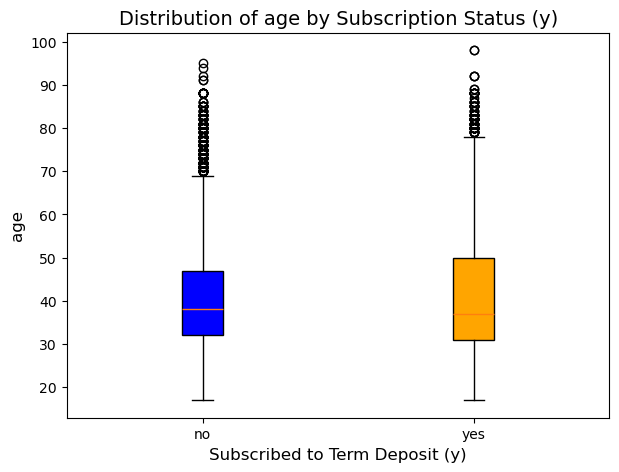

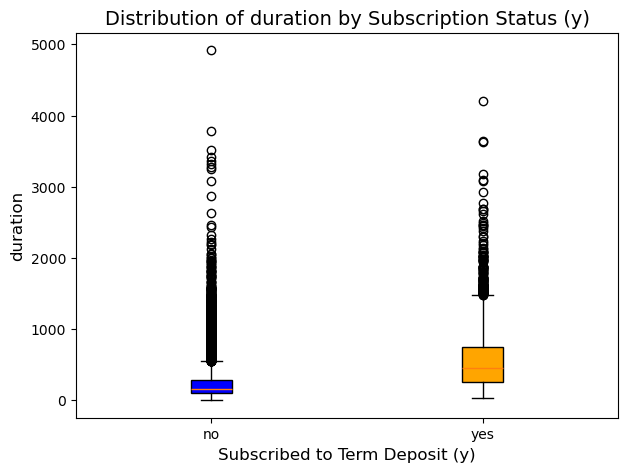

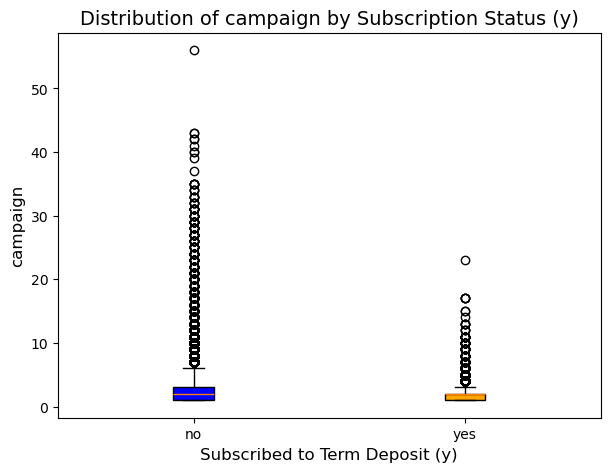

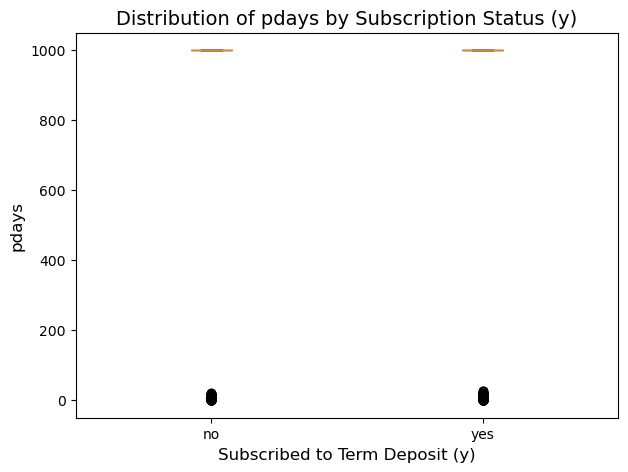

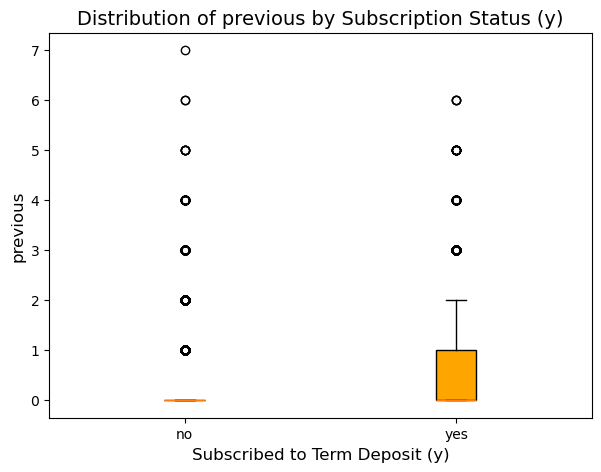

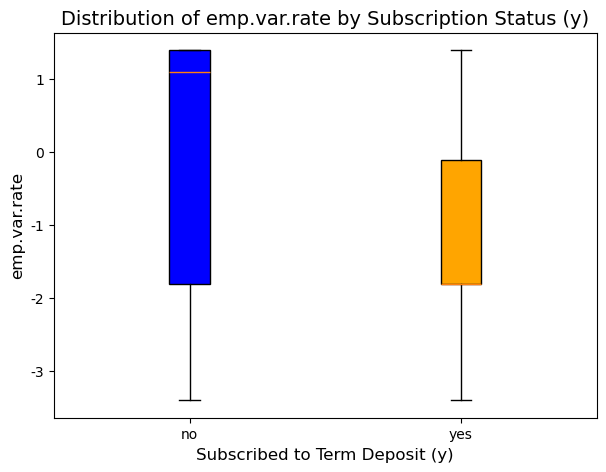

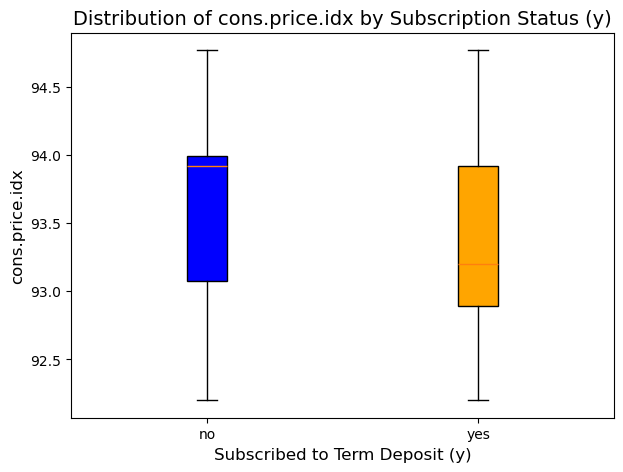

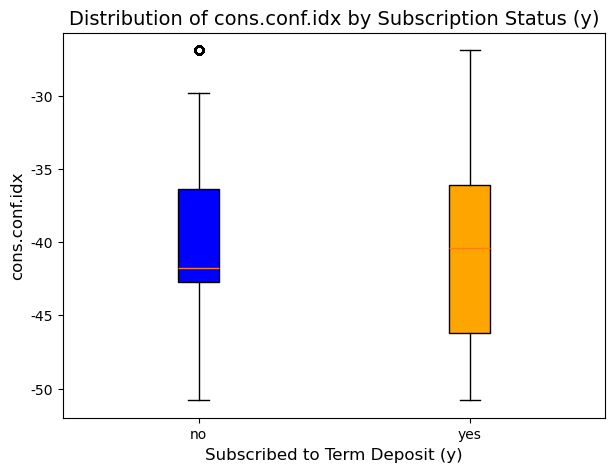

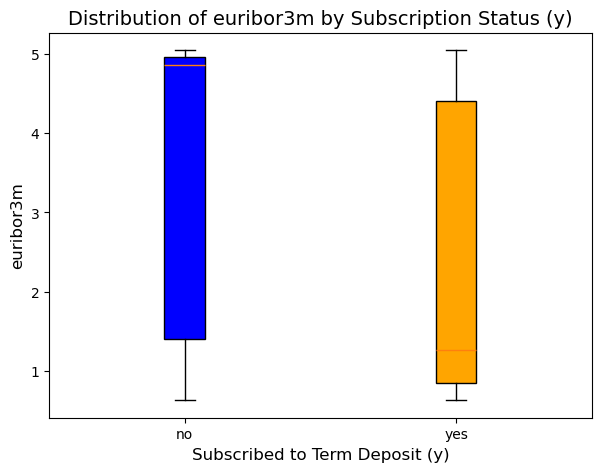

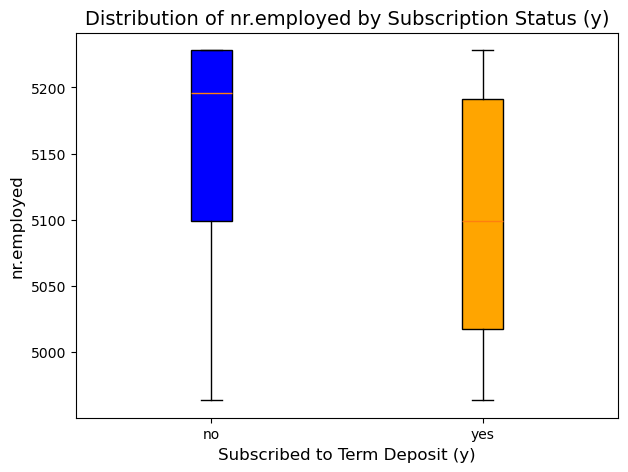

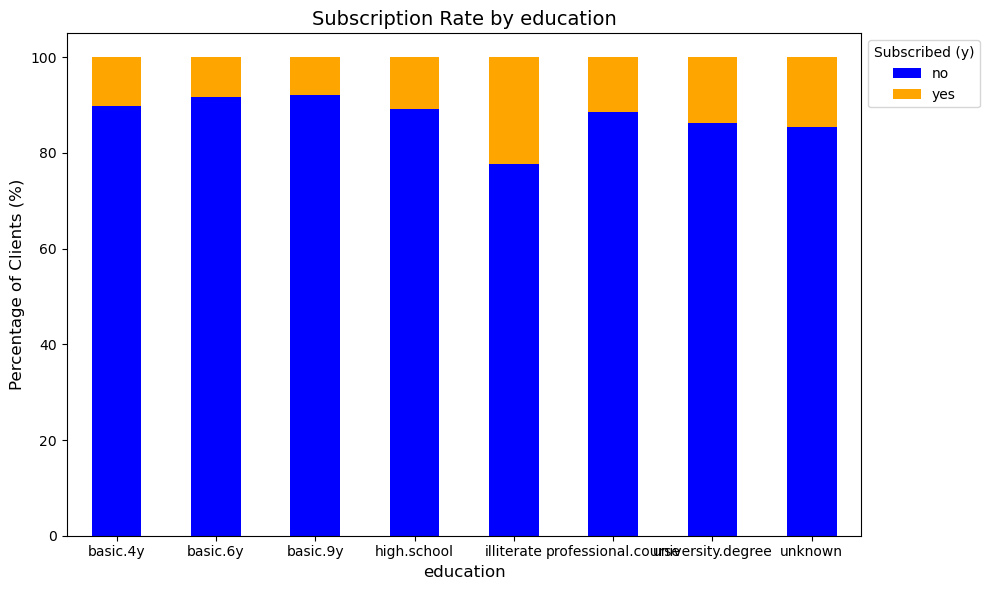

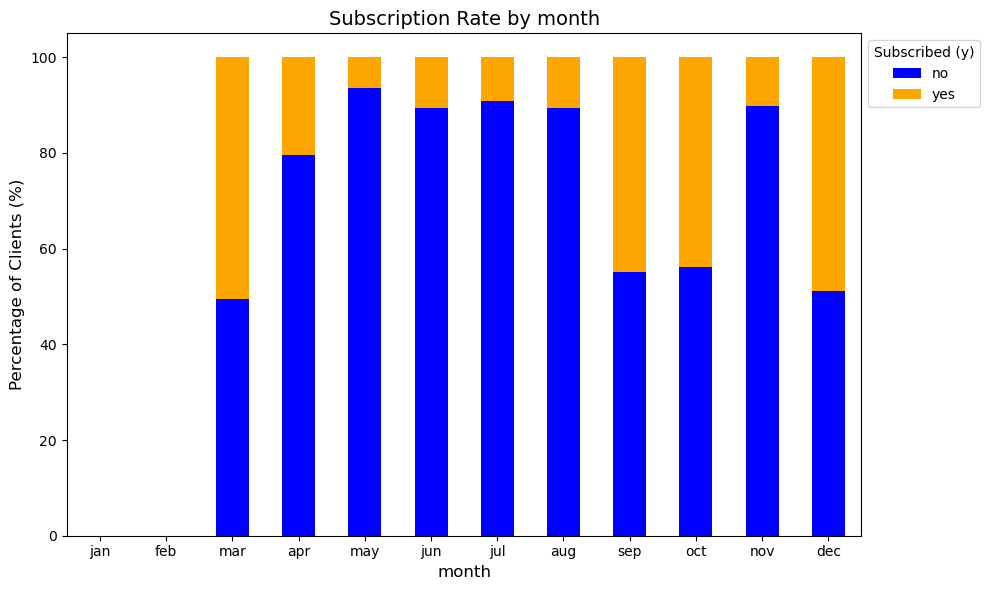

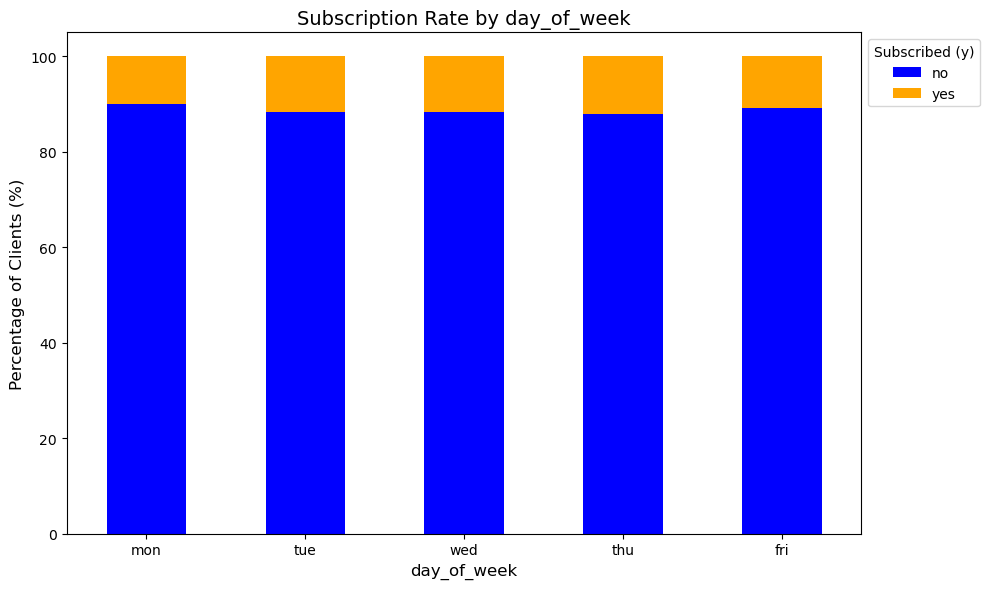

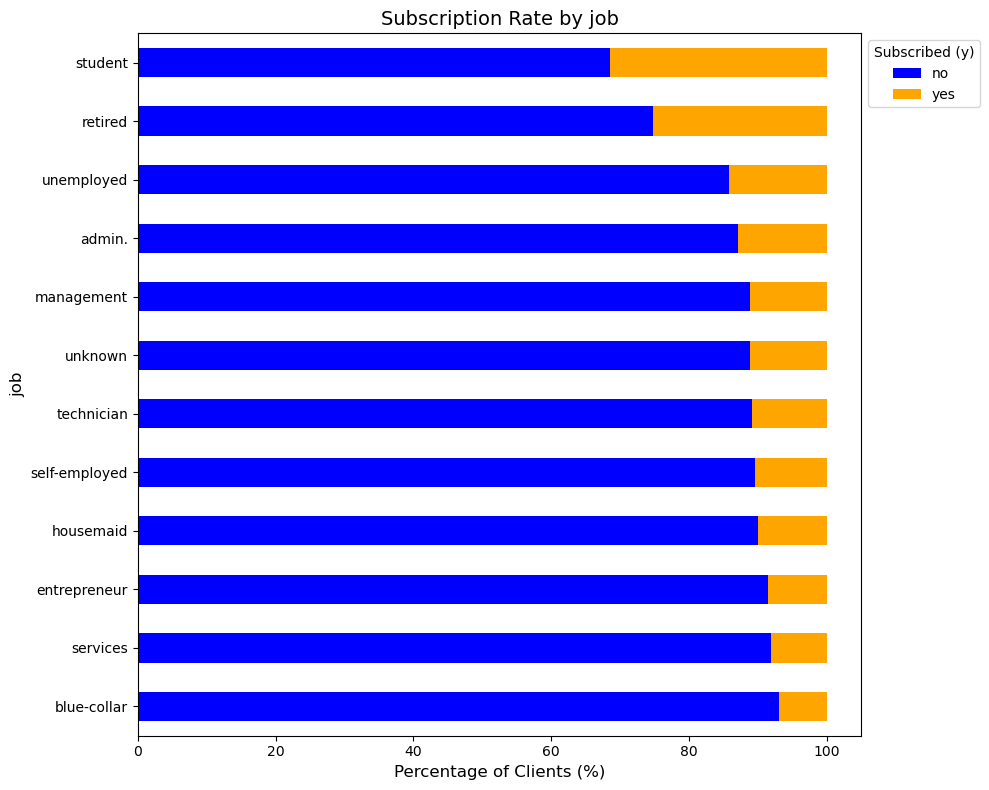

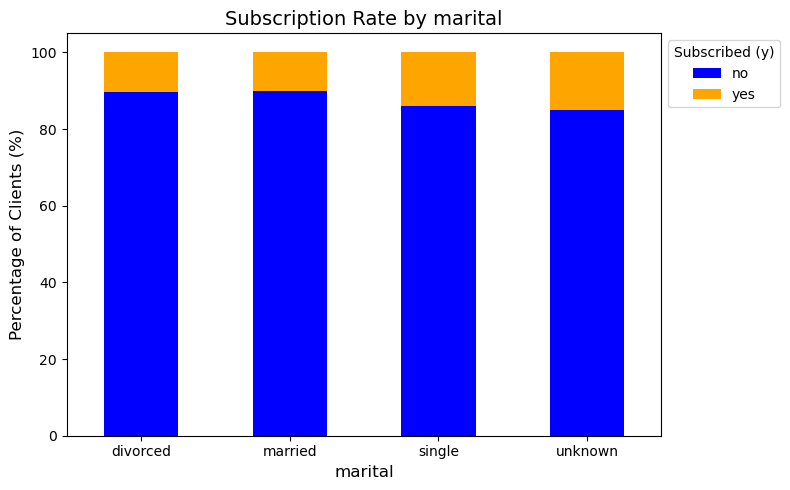

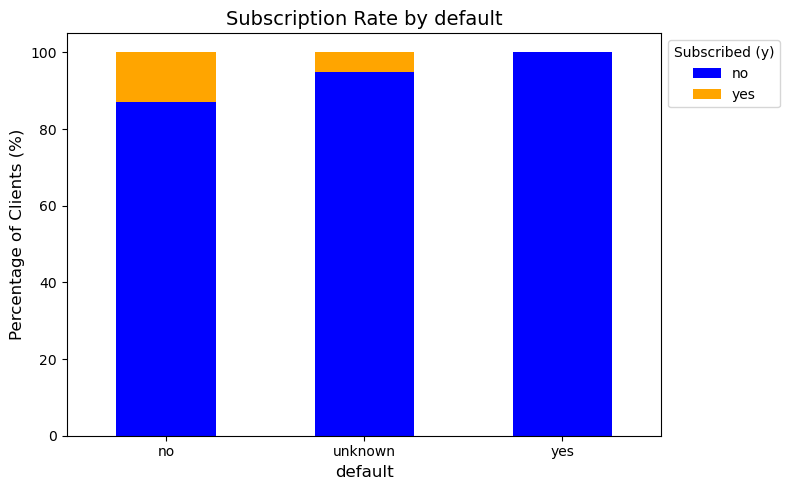

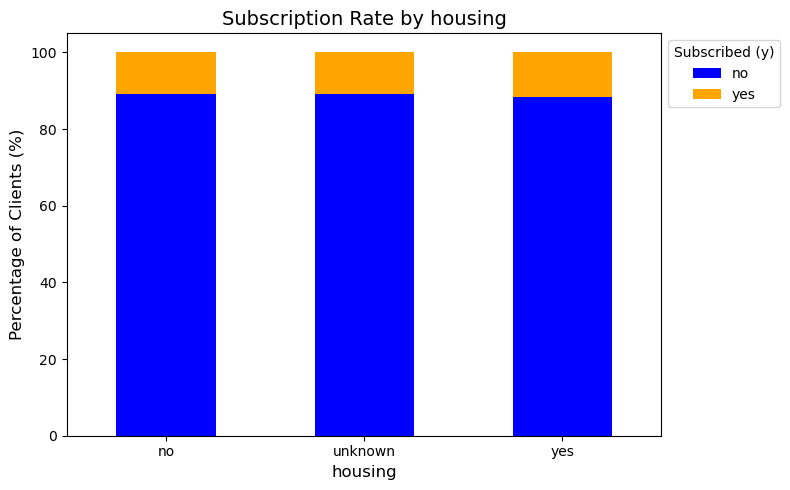

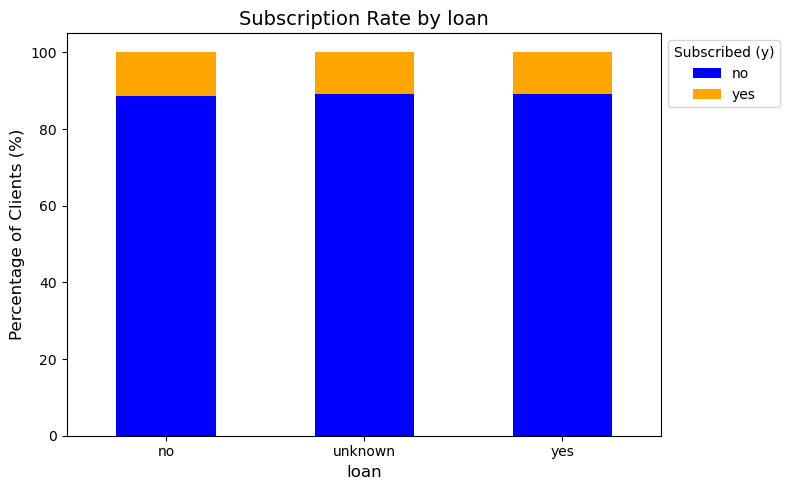

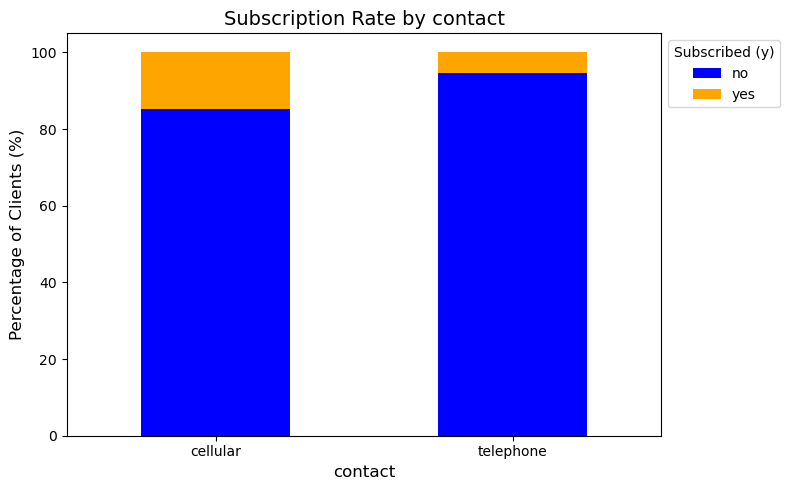

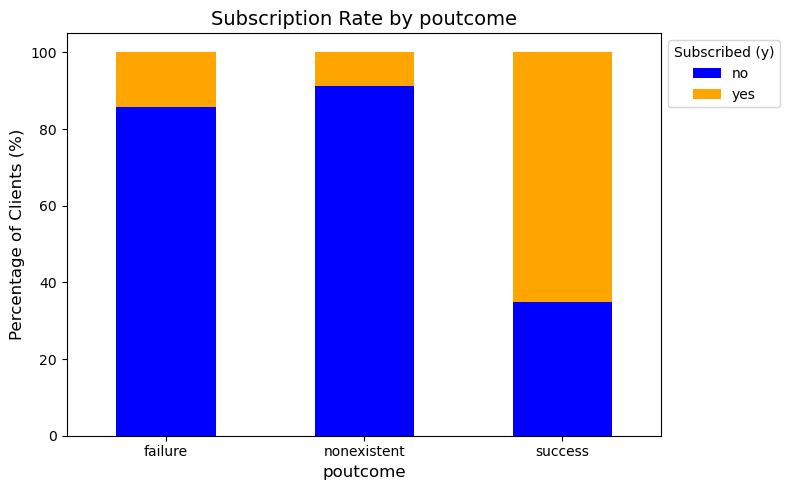

In [13]:
plt.rcParams['axes.unicode_minus'] = False

continuous_cols = ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx',
                  'cons.conf.idx', 'euribor3m', 'nr.employed']

for col in continuous_cols:
    plt.figure(figsize=(7, 5))
    
    data_to_plot = [
        df[df['y'] == 'no'][col].dropna(),
        df[df['y'] == 'yes'][col].dropna()
    ]
    
    bp = plt.boxplot(data_to_plot, patch_artist=True, tick_labels=['no', 'yes'])
    
    colors = ['blue', 'orange']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    plt.title(f'Distribution of {col} by Subscription Status (y)', fontsize=14)
    plt.xlabel('Subscribed to Term Deposit (y)', fontsize=12)
    plt.ylabel(col, fontsize=12)
    
    plt.show()

ordinal_cols = ['education', 'month', 'day_of_week'] 

month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
education_order = ["basic.4y","basic.6y","basic.9y","high.school","illiterate","professional.course","university.degree","unknown"]
day_order = ["mon","tue","wed","thu","fri"]

order_map = {
    'month': month_order,
    'education': education_order,
    'day_of_week': day_order
}

for col in ordinal_cols:
    cross_tab = pd.crosstab(df[col], df['y'])
    cross_tab_norm = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100
    
    if col in order_map:
        cross_tab_norm = cross_tab_norm.reindex(order_map[col])
    
    ax = cross_tab_norm.plot(kind='bar', stacked=True, figsize=(10, 6),
                             color=['blue', 'orange']) 
    
    plt.title(f'Subscription Rate by {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Percentage of Clients (%)', fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(title='Subscribed (y)', loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

categorical_cols = ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'poutcome']

for col in categorical_cols:
    cross_tab = pd.crosstab(df[col], df['y'])
    cross_tab_norm = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100
    
    if col == 'job':
        cross_tab_norm = cross_tab_norm.sort_values(by='yes')
        
    if col == 'job':
       
        ax = cross_tab_norm.plot(kind='barh', stacked=True, figsize=(10, 8),
                                 color=['blue', 'orange']) 
        plt.xlabel('Percentage of Clients (%)', fontsize=12)
        plt.ylabel(col, fontsize=12)
    else:
        # ***** 修正后的代码 *****
        ax = cross_tab_norm.plot(kind='bar', stacked=True, figsize=(8, 5),
                                 color=['blue', 'orange'])
        plt.xlabel(col, fontsize=12)
        plt.ylabel('Percentage of Clients (%)', fontsize=12)
        plt.xticks(rotation=0)
    
    plt.title(f'Subscription Rate by {col}', fontsize=14)
    plt.legend(title='Subscribed (y)', loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()
    

Generating Correlation Heatmap (Matplotlib-only)...


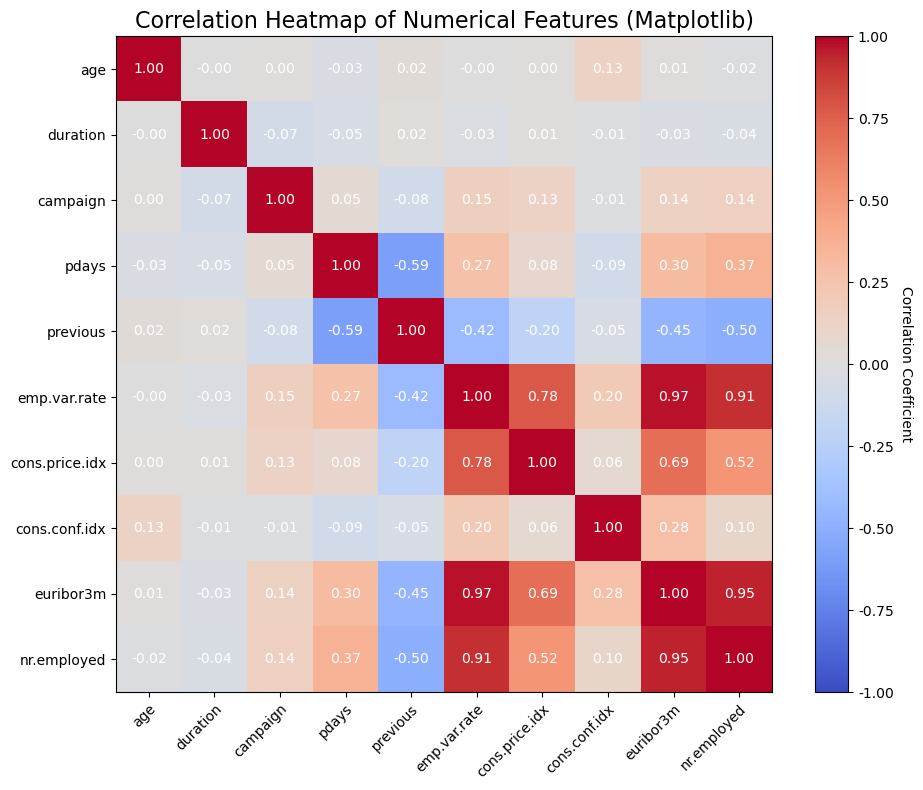

In [15]:
print("Generating Correlation Heatmap (Matplotlib-only)...")

numeric_cols = ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx',
                  'cons.conf.idx', 'euribor3m', 'nr.employed']

corr_matrix = df[numeric_cols].corr()
labels = corr_matrix.columns
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Correlation Coefficient', rotation=-90, va="bottom")

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
         rotation_mode="anchor")

for i in range(len(labels)):
    for j in range(len(labels)):
        text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                       ha="center", va="center", color="w") 

ax.set_title('Correlation Heatmap of Numerical Features (Matplotlib)', fontsize=16)

fig.tight_layout()
plt.show()


Generating KDE plots for: age, duration, campaign, pdays, previous, emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed


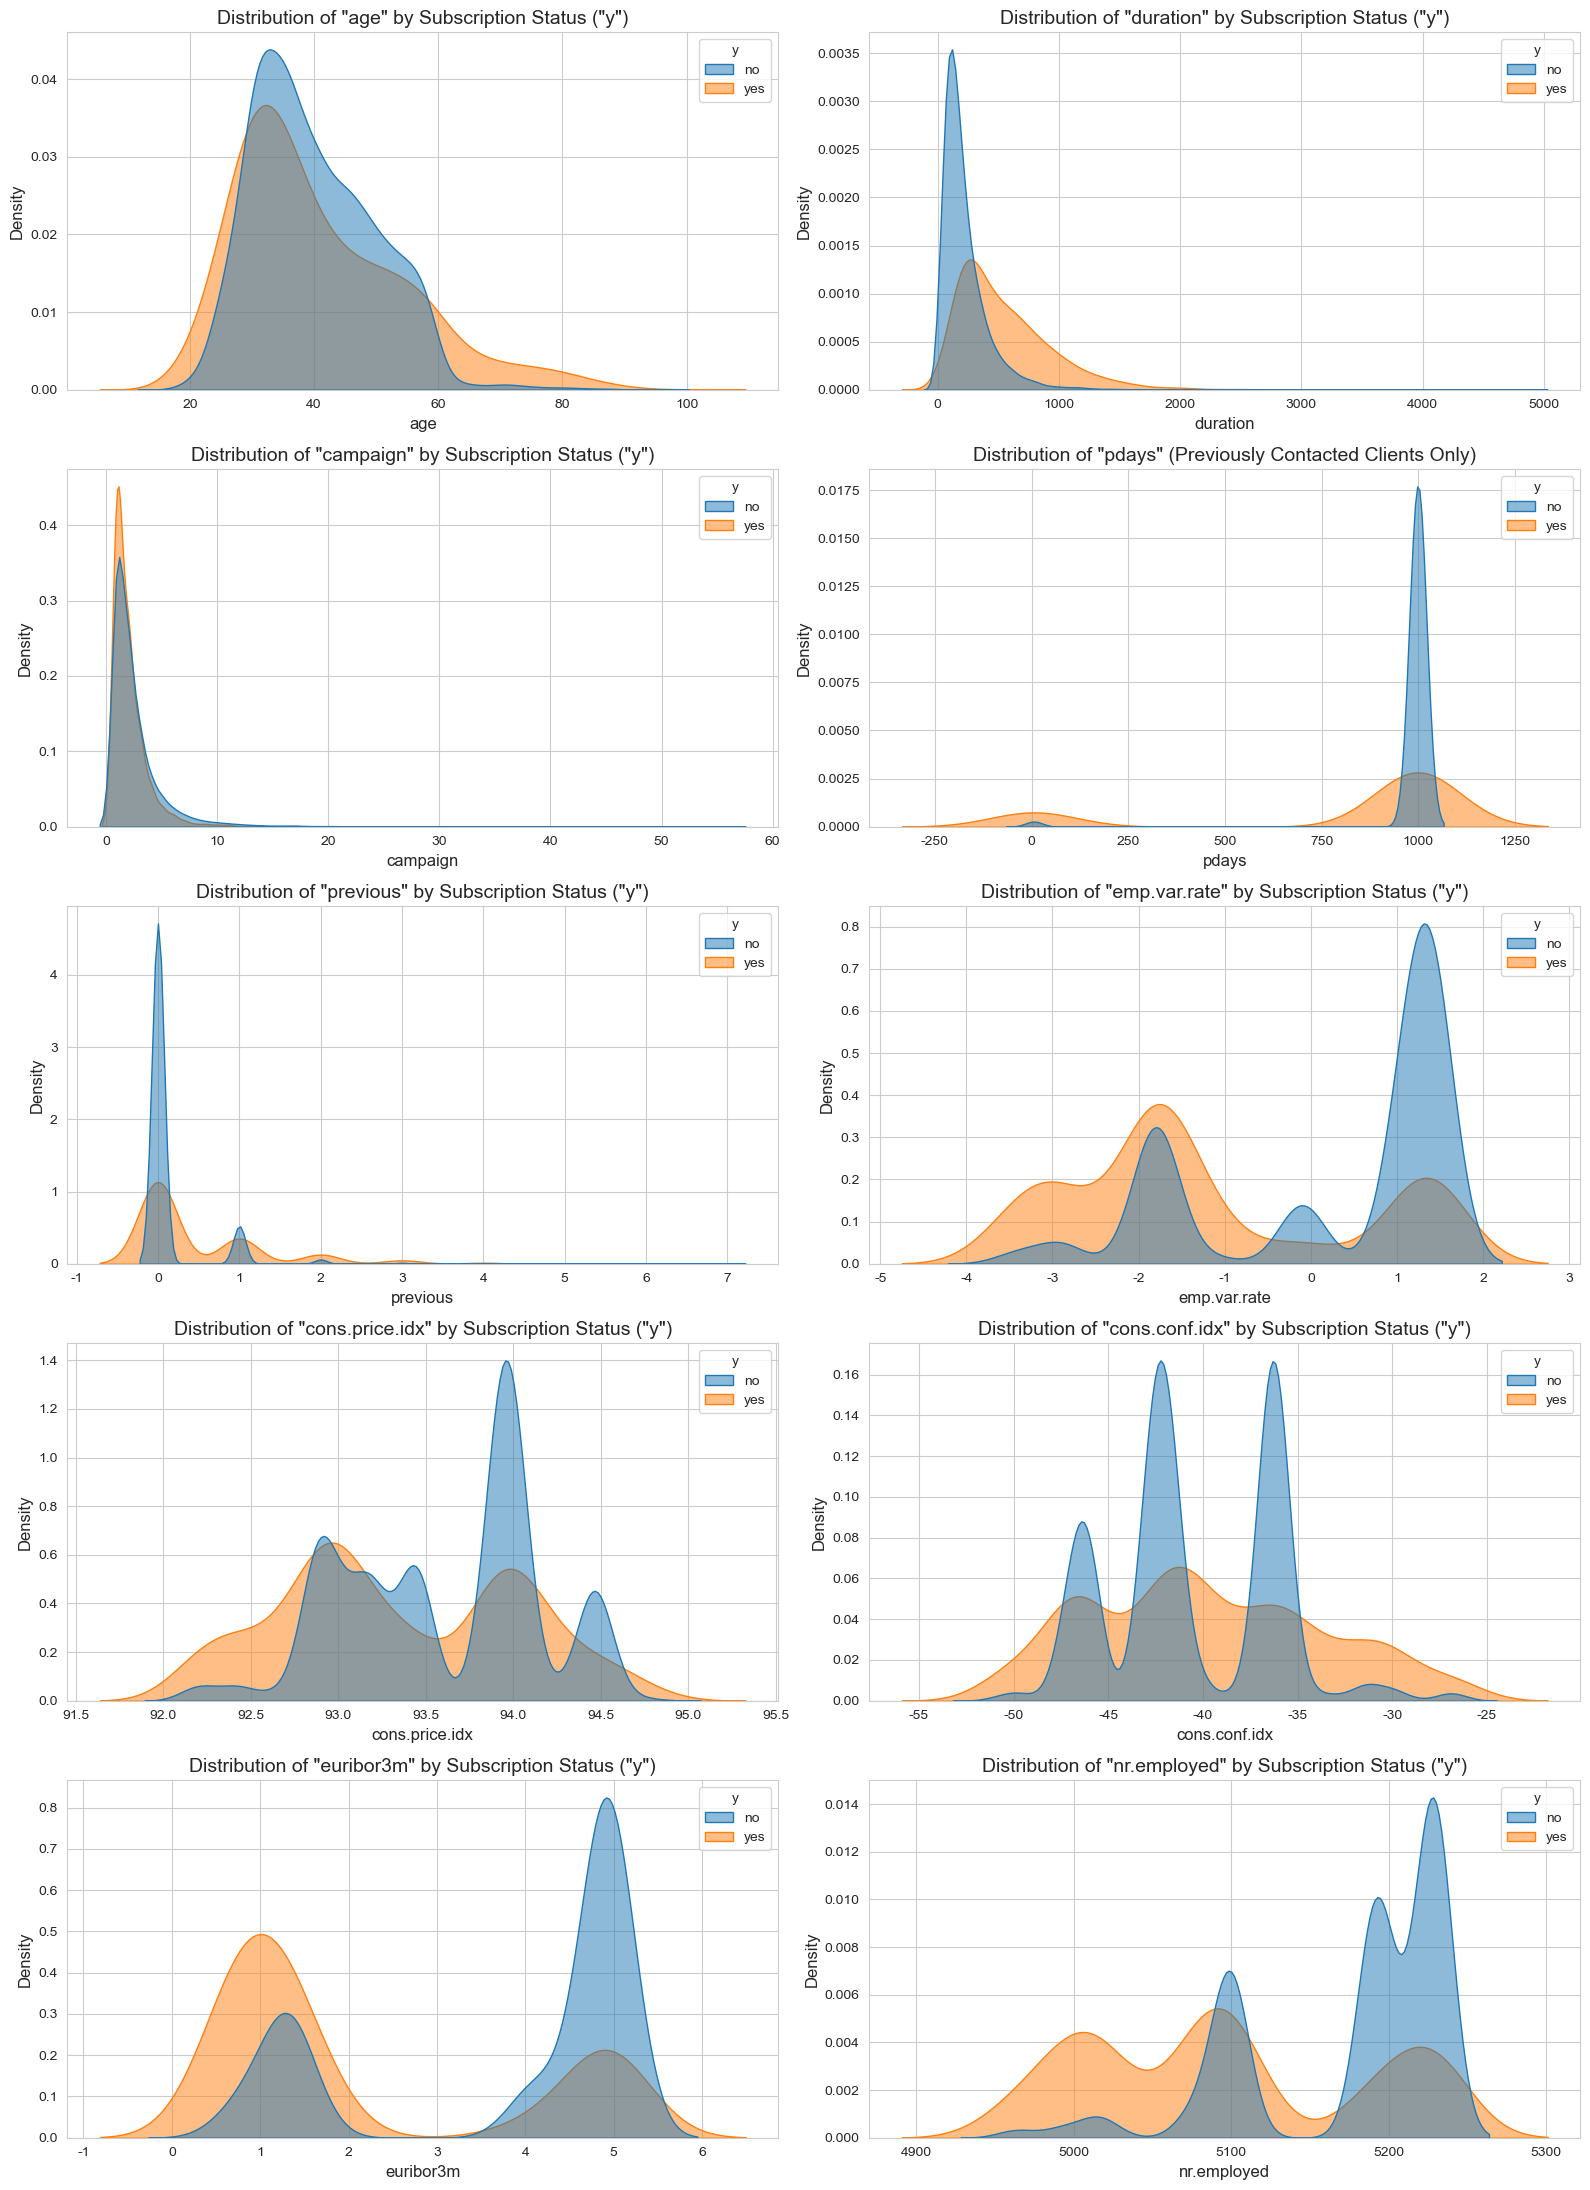

In [66]:
numeric_cols = ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx',
                  'cons.conf.idx', 'euribor3m', 'nr.employed']
target_col = 'y'
sns.set_style("whitegrid")
fig, axes = plt.subplots(5, 2, figsize=(16, 22))
axes_flat = axes.flat

print(f"\nGenerating KDE plots for: {', '.join(numeric_cols)}")

for i, col in enumerate(numeric_cols):
    ax = axes_flat[i]
        
    if col == 'pdays':
        plot_df = df[df['pdays'] > -1]
        title = f'Distribution of "{col}" (Previously Contacted Clients Only)'
    else:
        plot_df = df
        title = f'Distribution of "{col}" by Subscription Status ("{target_col}")'

    sns.kdeplot(
        data=plot_df,
        x=col,
        hue=target_col,
        fill=True,
        common_norm=False,
        alpha=0.5,
        ax=ax,
        bw_adjust=1.5 
    )
        
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    
if len(numeric_cols) < len(axes_flat):
    axes_flat[len(numeric_cols)].set_visible(False)
        
plt.tight_layout()

output_filename = 'all_numeric_distributions.png'
plt.savefig(output_filename)

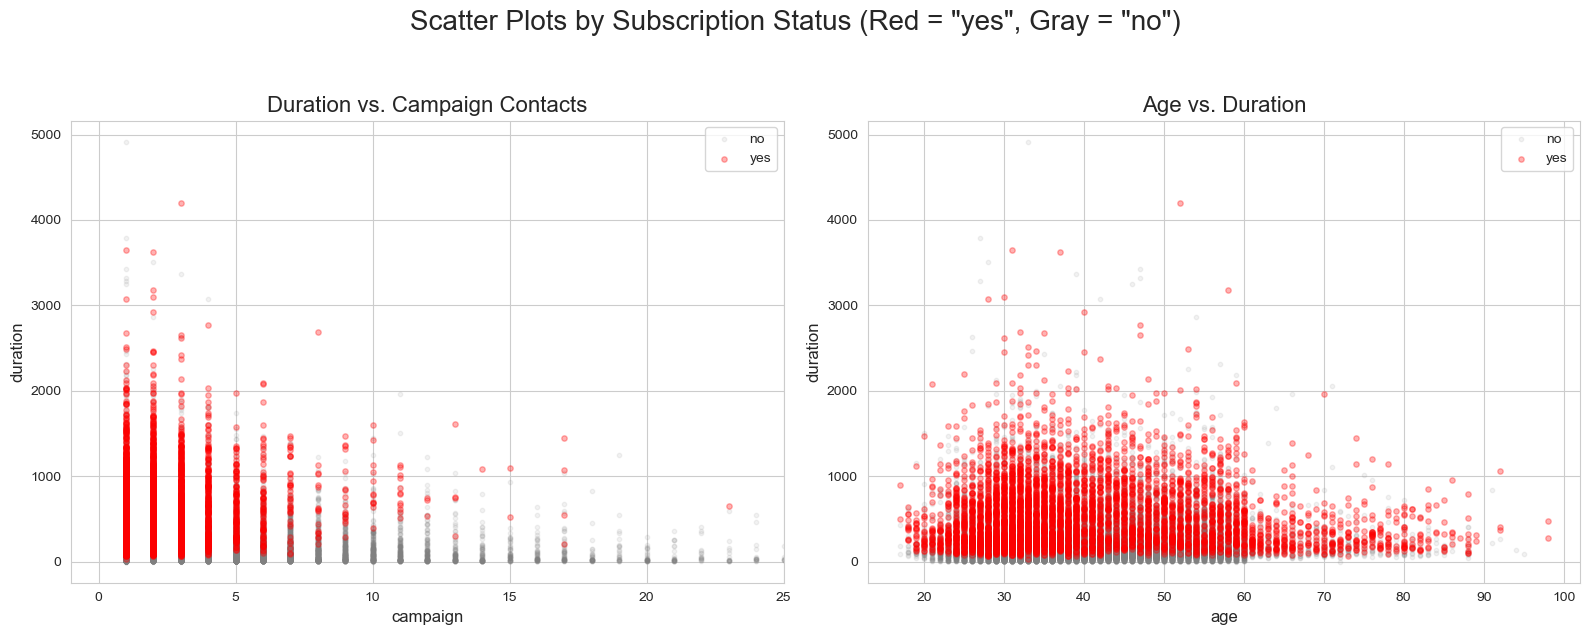

In [68]:
df_yes = df[df['y'] == 'yes']
df_no = df[df['y'] == 'no']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fig.suptitle('Scatter Plots by Subscription Status (Red = "yes", Gray = "no")', 
             fontsize=20, y=1.05)

def plot_layered_scatter(ax, x_col, y_col, title, x_lim=None, y_lim=None, y_scale='linear', x_scale='linear'):
    ax.scatter(df_no[x_col], df_no[y_col], 
               alpha=0.1, label='no', c='gray', s=10)
    ax.scatter(df_yes[x_col], df_yes[y_col], 
               alpha=0.3, label='yes', c='red', s=15)
       
    ax.set_title(title, fontsize=16)
    ax.set_xlabel(x_col, fontsize=12)
    ax.set_ylabel(y_col, fontsize=12)
    ax.legend()
       
    if x_lim:
        ax.set_xlim(x_lim)
    if y_lim:
        ax.set_ylim(y_lim)
       
    if y_scale == 'symlog':
        ax.set_yscale('symlog')
    if x_scale == 'symlog':
        ax.set_xscale('symlog')
        
# Plot 1: duration vs. campaign
plot_layered_scatter(axes[0], 'campaign', 'duration', 'Duration vs. Campaign Contacts', x_lim=(-1, 25))

# Plot 2: age vs. duration
plot_layered_scatter(axes[1], 'age', 'duration', 'Age vs. Duration')

plt.tight_layout()
output_filename = 'two_scatter_plots_analysis.png'
plt.savefig(output_filename)
plt.show()

Overall Mean Subscription Rate: 11.27%


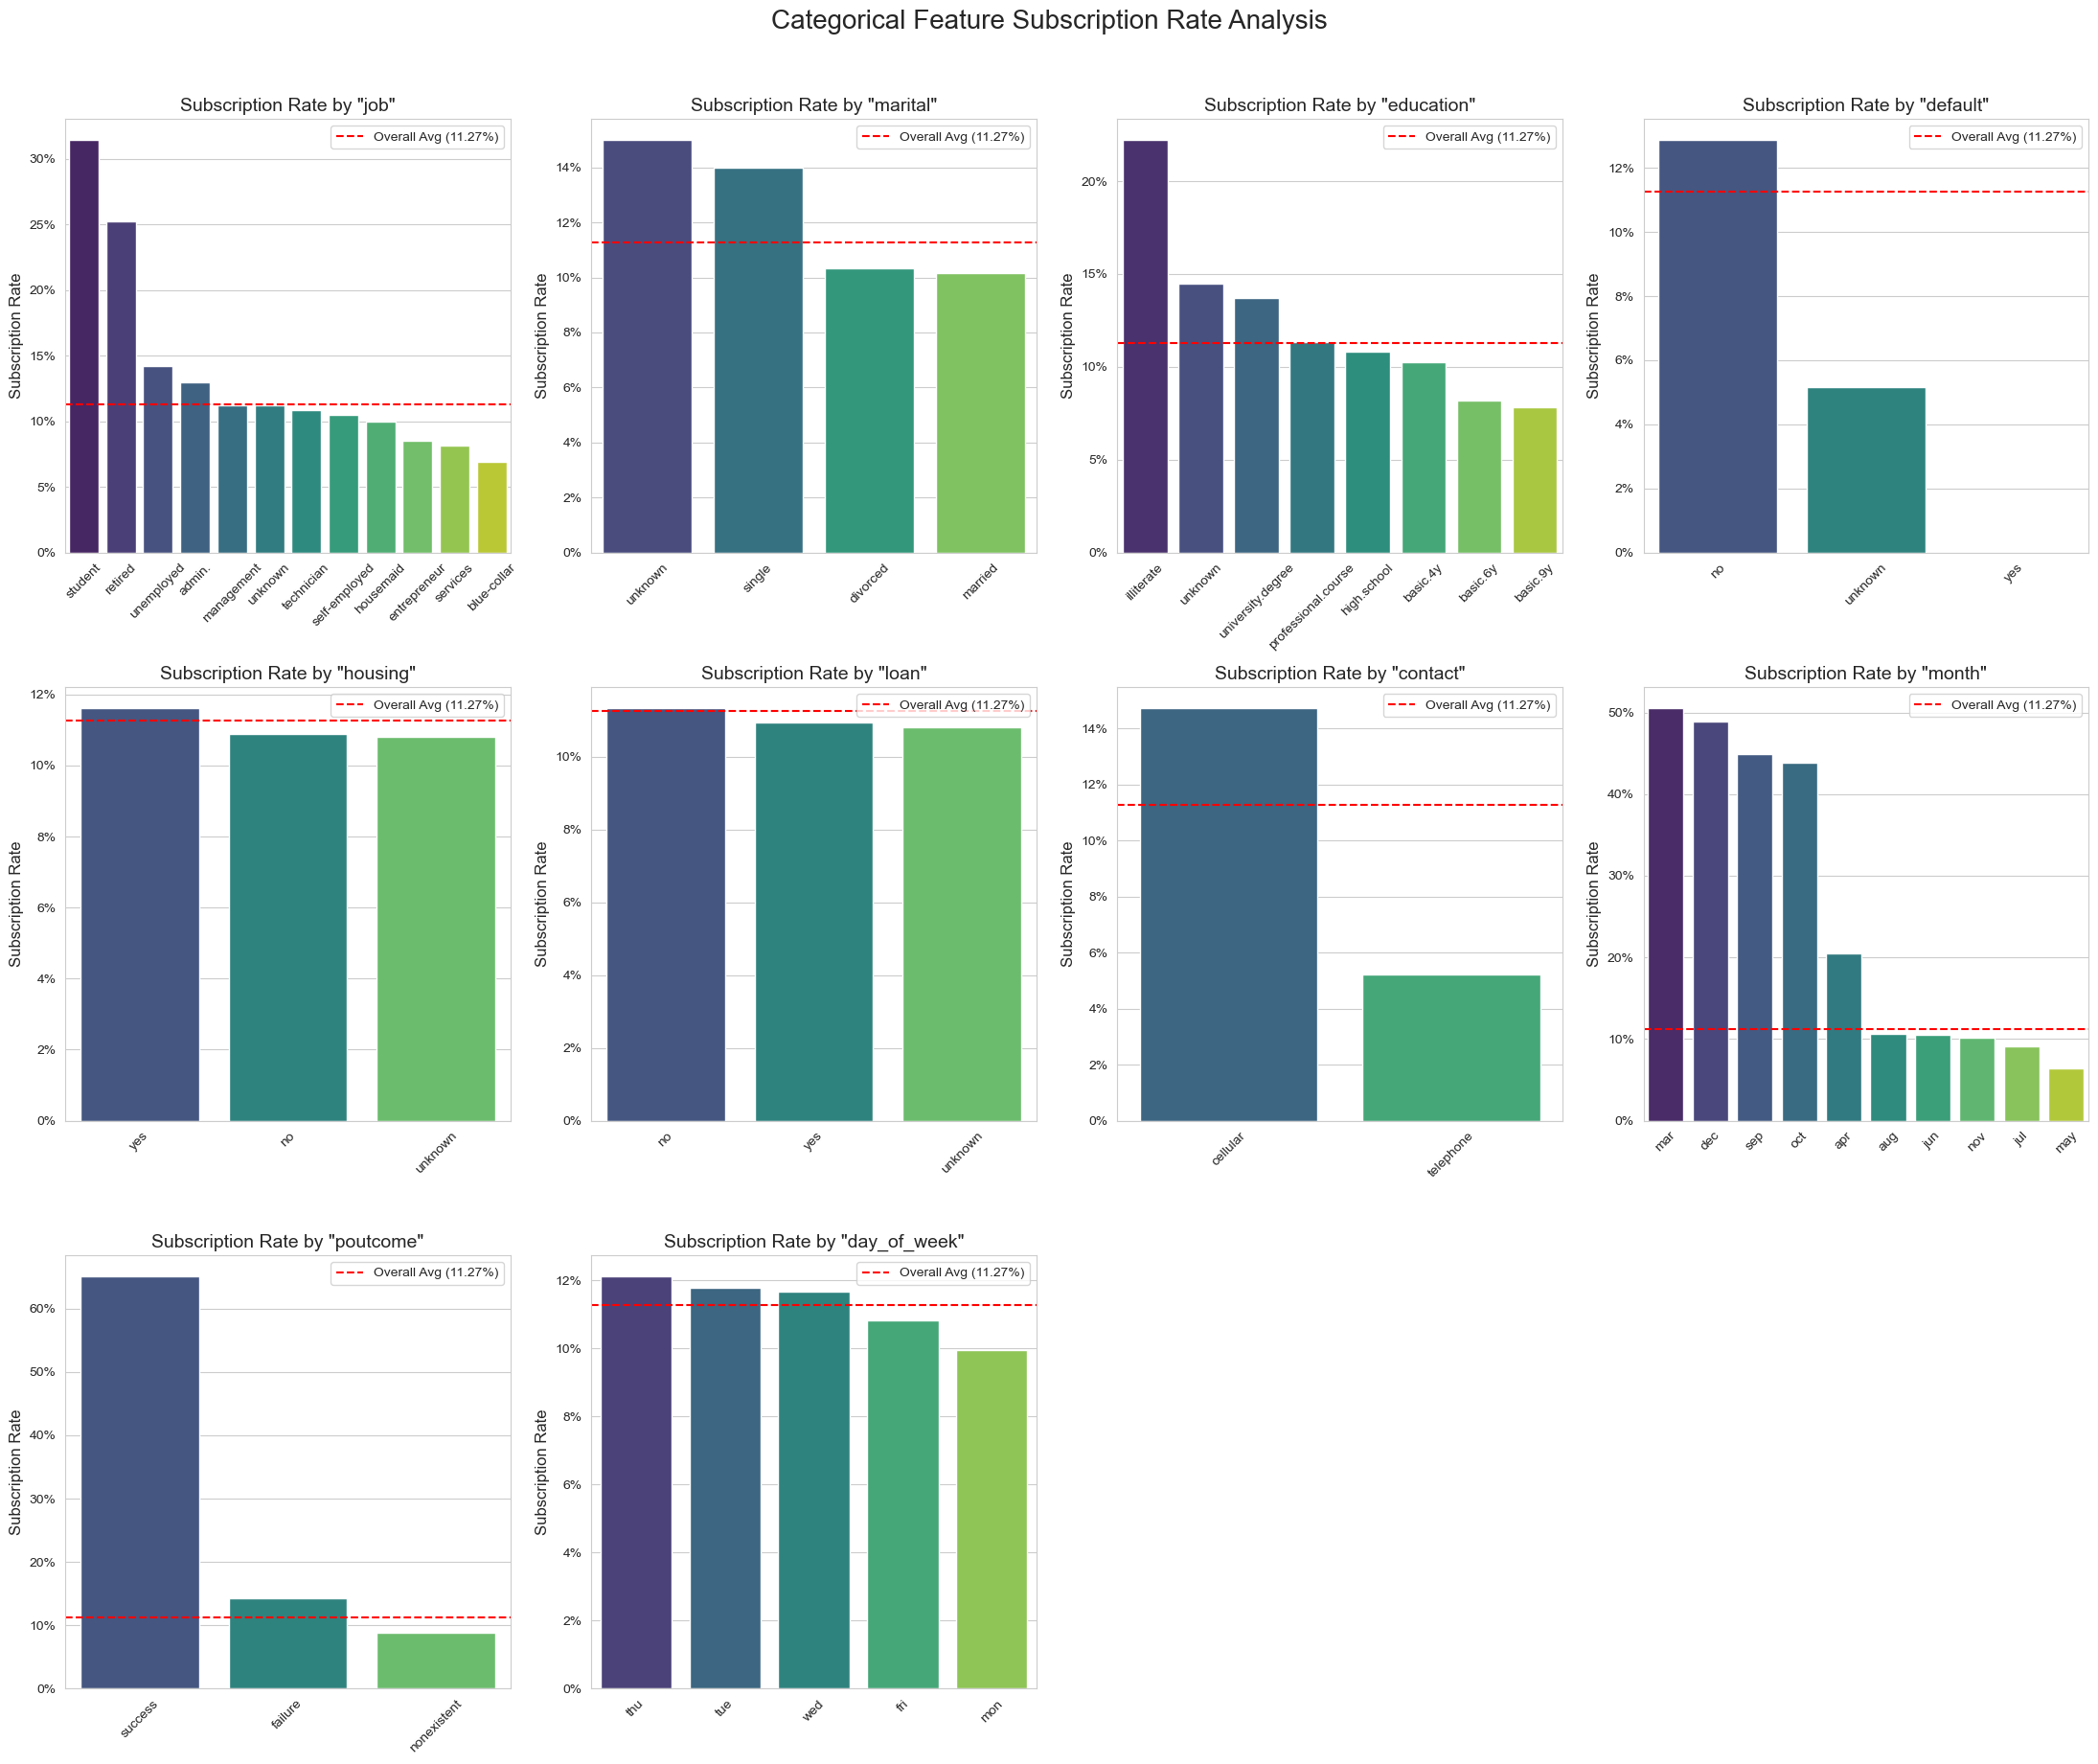

In [70]:
categorical_cols = [
    'job', 'marital', 'education', 'default', 
    'housing', 'loan', 'contact', 'month', 'poutcome', 'day_of_week'
]

if df['y'].dtype == 'object':
    df['y_numeric'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)
else:
    df['y_numeric'] = df['y']

overall_mean_rate = df['y_numeric'].mean()
print(f"Overall Mean Subscription Rate: {overall_mean_rate:.2%}")

fig, axes = plt.subplots(3, 4, figsize=(22, 18))
fig.suptitle('Categorical Feature Subscription Rate Analysis', fontsize=20, y=1.02)
axes_flat = axes.flat

for i, col in enumerate(categorical_cols):
    ax = axes_flat[i]
    
    rate_df = df.groupby(col)['y_numeric'].mean().reset_index()
    rate_df = rate_df.sort_values('y_numeric', ascending=False)

    sns.barplot(
        data=rate_df, 
        x=col, 
        y='y_numeric', 
        ax=ax,
        palette='viridis',
        hue=col,            
        legend=False        
    )
    
    ax.axhline(
        overall_mean_rate, 
        ls='--', 
        color='red', 
        label=f'Overall Avg ({overall_mean_rate:.2%})'
    )
    
    ax.set_title(f'Subscription Rate by "{col}"', fontsize=14)
    ax.set_xlabel('') 
    ax.set_ylabel('Subscription Rate', fontsize=12)

    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    
    ax.tick_params(axis='x', labelrotation=45)
    
    ax.legend()

for j in range(len(categorical_cols), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
output_filename = 'categorical_subscription_rates_final.png'
plt.savefig(output_filename)
plt.show()

总行数: 41188, 总特征数: 22
           Missing_Percentage
default              0.208726
education            0.042027
housing              0.024036
loan                 0.024036
job                  0.008012
marital              0.001942


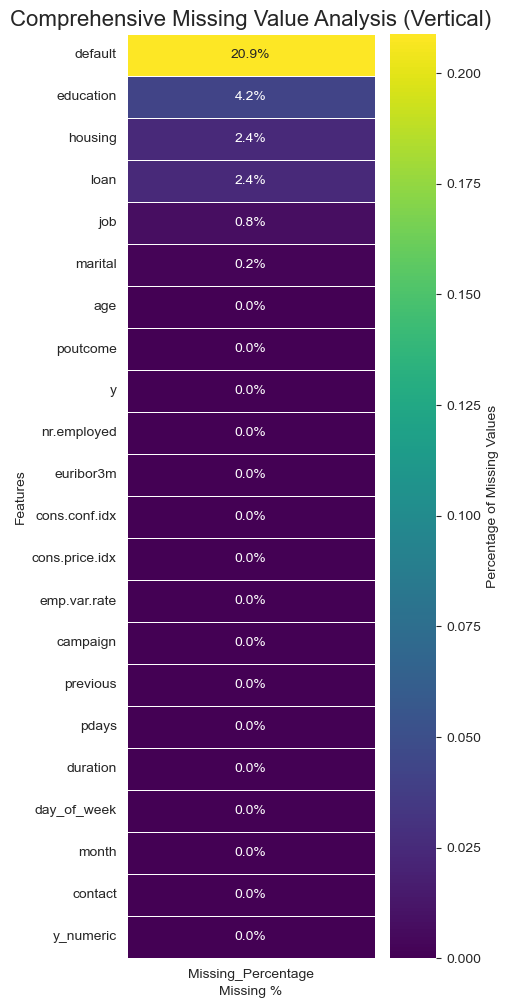

In [72]:
total_rows = len(df)
all_columns = df.columns
print(f"总行数: {total_rows}, 总特征数: {len(all_columns)}")

missing_pct = {}

for col in all_columns:
    if df[col].dtype == 'object':
        na_count = df[col].isnull().sum()
        
        empty_count = (df[col].str.strip() == '').sum()
        
        unknown_count = 0
        if col != 'poutcome': 
            unknown_count = (df[col] == 'unknown').sum()
        
        total_missing = na_count + unknown_count + empty_count
        
    else:
        total_missing = df[col].isnull().sum()
        
    missing_pct[col] = total_missing / total_rows

missing_df_heatmap = pd.DataFrame.from_dict(missing_pct, orient='index', columns=['Missing_Percentage'])

missing_df_heatmap = missing_df_heatmap.sort_values('Missing_Percentage', ascending=False)

print(missing_df_heatmap[missing_df_heatmap['Missing_Percentage'] > 0])

# plot
plt.figure(figsize=(4, 12))

heatmap = sns.heatmap(
    missing_df_heatmap, 
    annot=True,    
    fmt='.1%',     
    cmap='viridis', 
    cbar=True,
    cbar_kws={'label': 'Percentage of Missing Values'},
    linewidths=0.5, 
    linecolor='white'
)

plt.title('Comprehensive Missing Value Analysis (Vertical)', fontsize=16)
plt.ylabel('Features') 
plt.xlabel('Missing %') 
plt.yticks(rotation=0)

output_filename = 'final_missing_value_heatmap.png'
plt.savefig(output_filename, bbox_inches='tight')
plt.show()